In [1]:
# Test script 3

In [10]:
import pyreadr

# Load Rdata file
result = pyreadr.read_r("/glade/work/awells/air_quality/GBD2016_PREDPOP_FINAL.RData")

# result is a dictionary with R objects
print(result.keys())

# Extract your dataframe
df = result["mydata2"]


odict_keys(['mydata2'])


In [11]:
import pandas as pd
import xarray as xr

# Step 1. Select PM2.5 columns (all years, all stats)
pm25_cols = [c for c in df.columns if "PM2.5" in c]

# Step 2. Melt to long format
df_long = df.melt(
    id_vars=["Latitude", "Longitude", "idgridcell", "Country", "region", "urban", "perurban"],
    value_vars=pm25_cols,
    var_name="variable",
    value_name="value"
)

# Step 3. Extract year and statistic type from column names
# e.g. "Median_PM2.5_2016" -> ("Median", 2016)
df_long["stat"] = df_long["variable"].str.extract(r"^(.*?)_PM2\.5")
df_long["year"] = df_long["variable"].str.extract(r"(\d{4})").astype(int)

# Step 4. Pivot so that stats become separate variables
df_wide = df_long.pivot_table(
    index=["year", "Latitude", "Longitude"],
    columns="stat",
    values="value"
).reset_index()

# Step 5. Convert to xarray
ds = df_wide.set_index(["year", "Latitude", "Longitude"]).to_xarray()

print(ds)


<xarray.Dataset> Size: 2GB
Dimensions:    (year: 11, Latitude: 1259, Longitude: 3600)
Coordinates:
  * year       (year) int64 88B 1990 1995 2000 2005 2010 ... 2013 2014 2015 2016
  * Latitude   (Latitude) float64 10kB -55.85 -55.75 -55.65 ... 69.85 69.95
  * Longitude  (Longitude) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
Data variables:
    Lower95    (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Mean       (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Median     (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Upper95    (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan


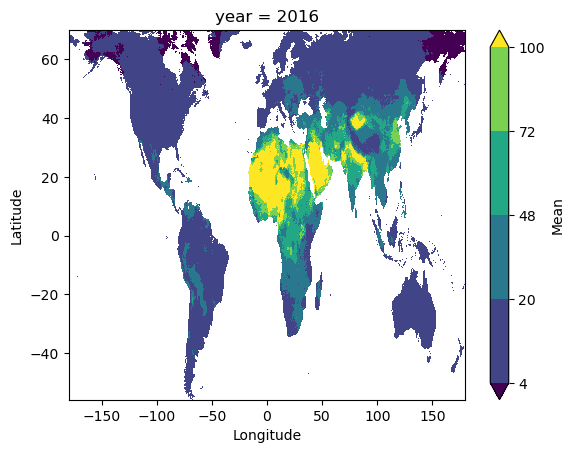

In [18]:
levels = [4, 20, 48, 72, 100]
ds["Mean"].sel(year=2016).plot(levels=levels)

In [21]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (year: 11, Latitude: 1259, Longitude: 3600)
Coordinates:
  * year       (year) int64 88B 1990 1995 2000 2005 2010 ... 2013 2014 2015 2016
  * Latitude   (Latitude) float64 10kB -55.85 -55.75 -55.65 ... 69.85 69.95
  * Longitude  (Longitude) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
Data variables:
    Lower95    (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Mean       (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Median     (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan
    Upper95    (year, Latitude, Longitude) float64 399MB nan nan nan ... nan nan